# Import Library

In [1]:
import os
import re
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium import LayerControl

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder


# Load Data

In [2]:
df = pd.read_csv('dataset_pju.csv')

In [3]:
gdf_kabtasik = gpd.read_file("maps_kabtasik.geojson")

# Exploratory Data Analysis

In [4]:
df.head()

,No,Lokasi,Tahun Anggaran,Titik Koordinat,Lokasi Pemasangan,Kondisi,Jenis PJU,Jenis Tiang,Jenis Lampu
0,1,"Puspa, Ds. Wakaf Kec. Bantarkalong",Tidak Diketahui,-7.520229 108.084697,Kanan,Baik,PJU Konvensional,Tiang Stang,Mercury
1,2,"Puspa, Ds. Wakaf Kec. Bantarkalong",Tidak Diketahui,-7.522890 108.084678,Kanan,Baik,PJU Konvensional,Tiang Tunggal,SON T
2,3,"Cibiru, Ds. Wakaf Kec. Bantarkalong",Tidak Diketahui,-7.529602 108.083917,Kanan,Baik,PJU Solar Cell,Tiang Tunggal,LED
3,4,"Leuwinanggung, Ds. Sukamaju, Kec. Bantarkalong",Tidak Diketahui,-7.537505 108.092379,Kanan,Baik,PJU Konvensional,Tiang Tunggal,SON T
4,5,"Datarrandu, Ds. Sukamaju, Kec. Bantarkalong",Tidak Diketahui,-7.537466 108.092989,Kanan,Baik,PJU Solar Cell,Tiang Tunggal,LED


In [5]:
# Melihat dimensi dataset
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

Jumlah baris: 5589
Jumlah kolom: 9


In [6]:
# Melihat informasi umum dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5589 entries, 0 to 5588
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   No                 5589 non-null   int64 
 1   Lokasi             5396 non-null   object
 2   Tahun Anggaran     5589 non-null   object
 3   Titik Koordinat    5517 non-null   object
 4   Lokasi Pemasangan  520 non-null    object
 5   Kondisi            5589 non-null   object
 6   Jenis PJU          5589 non-null   object
 7   Jenis Tiang        5589 non-null   object
 8   Jenis Lampu        5589 non-null   object
dtypes: int64(1), object(8)
memory usage: 393.1+ KB


In [7]:
df['Lokasi Pemasangan'] = df['Lokasi Pemasangan'].fillna('Tidak Diketahui')

In [8]:
# Melihat beberapa sample data
df.sample(5)

,No,Lokasi,Tahun Anggaran,Titik Koordinat,Lokasi Pemasangan,Kondisi,Jenis PJU,Jenis Tiang,Jenis Lampu
1793,1794,Jln Nagrak,Tidak Diketahui,-7.1929245 108.1690428,Tidak Diketahui,Baik,PJU Konvensional,Tiang Tunggal,LED
3496,3497,"JL PAHLAWAN KHZ MUSTOFA,Cipakat,Singaparna",Tidak Diketahui,-7.354480 108.119348,Tidak Diketahui,Baik,PJU Konvensional,Tiang Tunggal,SON T
3746,3747,"Kp tarate,Cikunir,Singaparna",Tidak Diketahui,-7.353328 108.147081,Tidak Diketahui,Baik,PJU Konvensional,Tiang Tunggal,SON T
5544,5545,NaN,Tidak Diketahui,-7.3773655 108.0365983,Tidak Diketahui,Baik,PJU Konvensional,Tiang Tunggal,SON T
2511,2512,Jl bendungan Padakembang Padakembang,Tidak Diketahui,-7.3044763 108.1080457,Tidak Diketahui,Rusak Ringan,PJU Konvensional,Tiang Tunggal,LED


# Memuat variabel kecamatan

In [9]:
# Daftar nama kecamatan
daftar_kecamatan = [
    "Bantarkalong", "Bojongasih", "Bojonggambir", "Ciawi", "Cibalong",
    "Cigalontang", "Cikalong", "Cikatomas", "Cineam", "Cipatujah",
    "Cisayong", "Culamega", "Gunung Tanjung", "Jamanis", "Jatiwaras",
    "Kadipaten", "Karang Jaya", "Karangnunggal", "Leuwisari", "Mangunreja",
    "Manonjaya", "Padakembang", "Pagerageung", "Pancatengah", "Parungponteng",
    "Puspahiang", "Rajapolah", "Salawu", "Salopa", "Sariwangi", "Singaparna",
    "Sodonghilir", "Sukahening", "Sukaraja", "Sukarame", "Sukaratu", "Sukaresik",
    "Tanjungjaya", "Taraju"
]

In [10]:
# Fungsi untuk ekstrak nama kecamatan dari kolom 'Lokasi'
def ekstrak_kecamatan(teks):
    if pd.isna(teks):
        return None
    for kec in daftar_kecamatan:
        # Gunakan regex agar bisa mengenali "Kec. Singaparna" atau "Singaparna"
        pola = r'\b' + re.escape(kec.lower()) + r'\b'
        if re.search(pola, teks.lower()):
            return kec
    return None

In [11]:
# Buat kolom 'Kecamatan' dari kolom 'Lokasi'
df["Kecamatan"] = df["Lokasi"].apply(ekstrak_kecamatan)

In [12]:
df.head()

,No,Lokasi,Tahun Anggaran,Titik Koordinat,Lokasi Pemasangan,Kondisi,Jenis PJU,Jenis Tiang,Jenis Lampu,Kecamatan
0,1,"Puspa, Ds. Wakaf Kec. Bantarkalong",Tidak Diketahui,-7.520229 108.084697,Kanan,Baik,PJU Konvensional,Tiang Stang,Mercury,Bantarkalong
1,2,"Puspa, Ds. Wakaf Kec. Bantarkalong",Tidak Diketahui,-7.522890 108.084678,Kanan,Baik,PJU Konvensional,Tiang Tunggal,SON T,Bantarkalong
2,3,"Cibiru, Ds. Wakaf Kec. Bantarkalong",Tidak Diketahui,-7.529602 108.083917,Kanan,Baik,PJU Solar Cell,Tiang Tunggal,LED,Bantarkalong
3,4,"Leuwinanggung, Ds. Sukamaju, Kec. Bantarkalong",Tidak Diketahui,-7.537505 108.092379,Kanan,Baik,PJU Konvensional,Tiang Tunggal,SON T,Bantarkalong
4,5,"Datarrandu, Ds. Sukamaju, Kec. Bantarkalong",Tidak Diketahui,-7.537466 108.092989,Kanan,Baik,PJU Solar Cell,Tiang Tunggal,LED,Bantarkalong


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5589 entries, 0 to 5588
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   No                 5589 non-null   int64 
 1   Lokasi             5396 non-null   object
 2   Tahun Anggaran     5589 non-null   object
 3   Titik Koordinat    5517 non-null   object
 4   Lokasi Pemasangan  5589 non-null   object
 5   Kondisi            5589 non-null   object
 6   Jenis PJU          5589 non-null   object
 7   Jenis Tiang        5589 non-null   object
 8   Jenis Lampu        5589 non-null   object
 9   Kecamatan          4302 non-null   object
dtypes: int64(1), object(9)
memory usage: 436.8+ KB


# Membersihkan Data

In [14]:
# Mengecek missing value
df.isnull().sum()

,0
No,0
Lokasi,193
Tahun Anggaran,0
Titik Koordinat,72
Lokasi Pemasangan,0
Kondisi,0
Jenis PJU,0
Jenis Tiang,0
Jenis Lampu,0
Kecamatan,1287


In [15]:
# Menghapus missing value
df.dropna(inplace=True)
df.isnull().sum()

,0
No,0
Lokasi,0
Tahun Anggaran,0
Titik Koordinat,0
Lokasi Pemasangan,0
Kondisi,0
Jenis PJU,0
Jenis Tiang,0
Jenis Lampu,0
Kecamatan,0


In [16]:
# Memastikan data sudah bersih
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4235 entries, 0 to 5395
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   No                 4235 non-null   int64 
 1   Lokasi             4235 non-null   object
 2   Tahun Anggaran     4235 non-null   object
 3   Titik Koordinat    4235 non-null   object
 4   Lokasi Pemasangan  4235 non-null   object
 5   Kondisi            4235 non-null   object
 6   Jenis PJU          4235 non-null   object
 7   Jenis Tiang        4235 non-null   object
 8   Jenis Lampu        4235 non-null   object
 9   Kecamatan          4235 non-null   object
dtypes: int64(1), object(9)
memory usage: 363.9+ KB


# Analisis Keterkaitan Antar Variabel

In [17]:
# Encoding semua kolom kategorikal menjadi angka
label_encoders = {}
df_encoded = df.copy()

for column in df_encoded.columns:
    if df_encoded[column].dtype == 'object':
        le = LabelEncoder()
        df_encoded[column] = le.fit_transform(df_encoded[column].astype(str))
        label_encoders[column] = le

In [18]:
# Pisahkan fitur dan target
X = df_encoded.drop(columns=['Kondisi'])
y = df_encoded['Kondisi']

In [19]:
# Bangun model Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

RandomForestClassifier(random_state=42)

In [20]:
# Hitung tingkat keterkaitan (feature importance)
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

In [21]:
# Tampilkan hasil dalam bentuk tabel
print("=== Tingkat Keterkaitan Antar Variabel terhadap Kondisi PJU ===")
print(importances)

=== Tingkat Keterkaitan Antar Variabel terhadap Kondisi PJU ===
No                   0.293879
Titik Koordinat      0.223548
Lokasi               0.176651
Jenis Lampu          0.143002
Kecamatan            0.098420
Jenis Tiang          0.055475
Jenis PJU            0.004249
Tahun Anggaran       0.003521
Lokasi Pemasangan    0.001254
dtype: float64


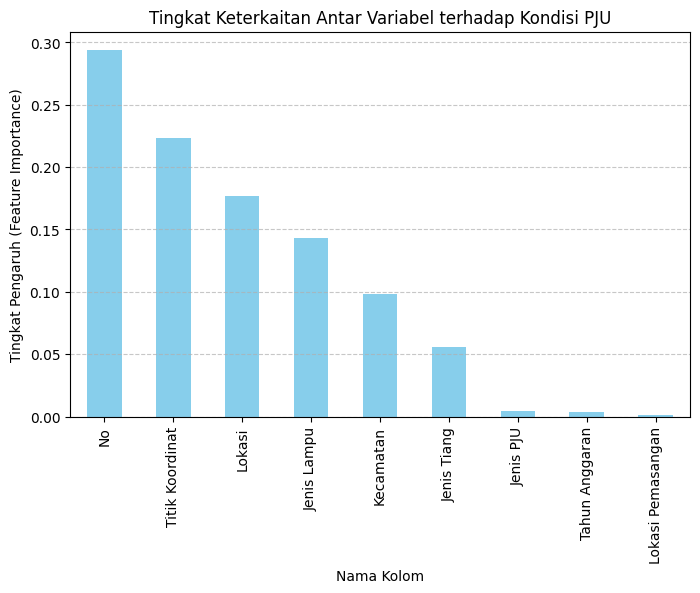

In [22]:
# Visualisasi hasil
plt.figure(figsize=(8, 5))
importances.plot(kind='bar', color='skyblue')
plt.title('Tingkat Keterkaitan Antar Variabel terhadap Kondisi PJU')
plt.xlabel('Nama Kolom')
plt.ylabel('Tingkat Pengaruh (Feature Importance)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [23]:
# Menghapus variabel yang tidak diperlukan
hapus = ['No', 'Lokasi', 'Tahun Anggaran', 'Lokasi Pemasangan']
df.drop(columns=hapus, inplace=True)
df.head()

,Titik Koordinat,Kondisi,Jenis PJU,Jenis Tiang,Jenis Lampu,Kecamatan
0,-7.520229 108.084697,Baik,PJU Konvensional,Tiang Stang,Mercury,Bantarkalong
1,-7.522890 108.084678,Baik,PJU Konvensional,Tiang Tunggal,SON T,Bantarkalong
2,-7.529602 108.083917,Baik,PJU Solar Cell,Tiang Tunggal,LED,Bantarkalong
3,-7.537505 108.092379,Baik,PJU Konvensional,Tiang Tunggal,SON T,Bantarkalong
4,-7.537466 108.092989,Baik,PJU Solar Cell,Tiang Tunggal,LED,Bantarkalong


# Klasifikasi kondisi PJU

In [24]:
# Melihat nilai unik dalam kolom 'Kondisi'
print("=== Nilai unik dalam kolom Kondisi ===")
print(df['Kondisi'].unique())

=== Nilai unik dalam kolom Kondisi ===
['Baik' 'Rusak Ringan' 'Rusak Berat']


In [25]:
# Buat kolom biner dari kolom 'Kondisi'
df['Kondisi_Biner'] = df['Kondisi'].apply(
    lambda x: 0 if str(x).strip().lower() == 'baik' else 1
)

# Cek hasilnya
print(df['Kondisi_Biner'].value_counts())
print("\nJumlah data kosong di Kondisi_Biner:", df['Kondisi_Biner'].isna().sum())

Kondisi_Biner
0    3777
1     458
Name: count, dtype: int64

Jumlah data kosong di Kondisi_Biner: 0


In [26]:
df.head()

,Titik Koordinat,Kondisi,Jenis PJU,Jenis Tiang,Jenis Lampu,Kecamatan,Kondisi_Biner
0,-7.520229 108.084697,Baik,PJU Konvensional,Tiang Stang,Mercury,Bantarkalong,0
1,-7.522890 108.084678,Baik,PJU Konvensional,Tiang Tunggal,SON T,Bantarkalong,0
2,-7.529602 108.083917,Baik,PJU Solar Cell,Tiang Tunggal,LED,Bantarkalong,0
3,-7.537505 108.092379,Baik,PJU Konvensional,Tiang Tunggal,SON T,Bantarkalong,0
4,-7.537466 108.092989,Baik,PJU Solar Cell,Tiang Tunggal,LED,Bantarkalong,0


Mengklasifikasikan kondisi PJU menjadi:

Baik = 0

Rusak = 1

# Bangun GeoDataFrame titik PJU & baca data GeoJSON

In [27]:
# Memisahkan kolom 'Titik Koordinat' menjadi Latitude dan Longitude
coords = df['Titik Koordinat'].str.split(' ', expand=True)

# Assign latitude and longitude, handling potential errors
df['Latitude'] = pd.to_numeric(coords[0], errors='coerce')
df['Longitude'] = pd.to_numeric(coords[1], errors='coerce')

print("Kolom 'Titik Koordinat' berhasil dipecah menjadi 'Latitude' dan 'Longitude'.")

Kolom 'Titik Koordinat' berhasil dipecah menjadi 'Latitude' dan 'Longitude'.


In [28]:
# GeoDataFrame titik
gdf_pju = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]),
    crs="EPSG:4326"
)

In [29]:
# Baca peta kecamatan
gdf_kecamatan = gpd.read_file("maps_kabtasik.geojson")
# Pastikan CRS WGS84
if gdf_kecamatan.crs is None or gdf_kecamatan.crs.to_epsg() != 4326:
    gdf_kecamatan = gdf_kecamatan.to_crs("EPSG:4326")

print("Kolom di geojson:", list(gdf_kecamatan.columns))
# Dari kamu: ['kd_propinsi','kd_dati2','kd_kecamatan','nm_kecamatan','geometry']
assert "nm_kecamatan" in gdf_kecamatan.columns, "Kolom 'nm_kecamatan' tidak ditemukan di GeoJSON."

Kolom di geojson: ['kd_propinsi', 'kd_dati2', 'kd_kecamatan', 'nm_kecamatan', 'geometry']


# Spatial Join: titik → kecamatan

In [30]:
# Spatial join (titik di dalam poligon)
# Gunakan predicate="within" (kalau ada titik di boundary, "intersects" juga ok)
gdf_joined = gpd.sjoin(gdf_pju, gdf_kecamatan[["nm_kecamatan","geometry"]], how="left", predicate="within")

In [31]:
# Simpan nama kecamatan final
gdf_joined = gdf_joined.rename(columns={"nm_kecamatan":"Kecamatan_Final"})


In [32]:
# Cek hasil
print("Contoh hasil spatial join:")
display(gdf_joined[["Latitude","Longitude","Kondisi","Kondisi_Biner","Kecamatan_Final"]].head())

Contoh hasil spatial join:


,Latitude,Longitude,Kondisi,Kondisi_Biner,Kecamatan_Final
0,-7.520229,108.084697,Baik,0,Bantarkalong
1,-7.522890,108.084678,Baik,0,Bantarkalong
2,-7.529602,108.083917,Baik,0,Bantarkalong
3,-7.537505,108.092379,Baik,0,Bantarkalong
4,-7.537466,108.092989,Baik,0,Bantarkalong


In [33]:
# Kalau ada titik yang masih NaN kecamatannya, berarti jatuh di luar polygon (cek koordinat/manual)
print("Jumlah titik tanpa kecamatan:", gdf_joined["Kecamatan_Final"].isna().sum())

Jumlah titik tanpa kecamatan: 1006


In [34]:
# Menghapus titik tanpa kecamatan
gdf_joined = gdf_joined.dropna(subset=["Kecamatan_Final"])

In [35]:
# Cek ulang
print("Jumlah titik tanpa kecamatan:", gdf_joined["Kecamatan_Final"].isna().sum())

Jumlah titik tanpa kecamatan: 0


In [36]:
# Mengecek jumlah data bersih
gdf_joined.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 3229 entries, 0 to 5395
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Titik Koordinat  3229 non-null   object  
 1   Kondisi          3229 non-null   object  
 2   Jenis PJU        3229 non-null   object  
 3   Jenis Tiang      3229 non-null   object  
 4   Jenis Lampu      3229 non-null   object  
 5   Kecamatan        3229 non-null   object  
 6   Kondisi_Biner    3229 non-null   int64   
 7   Latitude         3229 non-null   float64 
 8   Longitude        3229 non-null   float64 
 9   geometry         3229 non-null   geometry
 10  index_right      3229 non-null   float64 
 11  Kecamatan_Final  3229 non-null   object  
dtypes: float64(3), geometry(1), int64(1), object(7)
memory usage: 327.9+ KB


# Visualisasi

/tmp/ipython-input-2654152049.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Kondisi_Biner', data=gdf_joined, palette='crest')


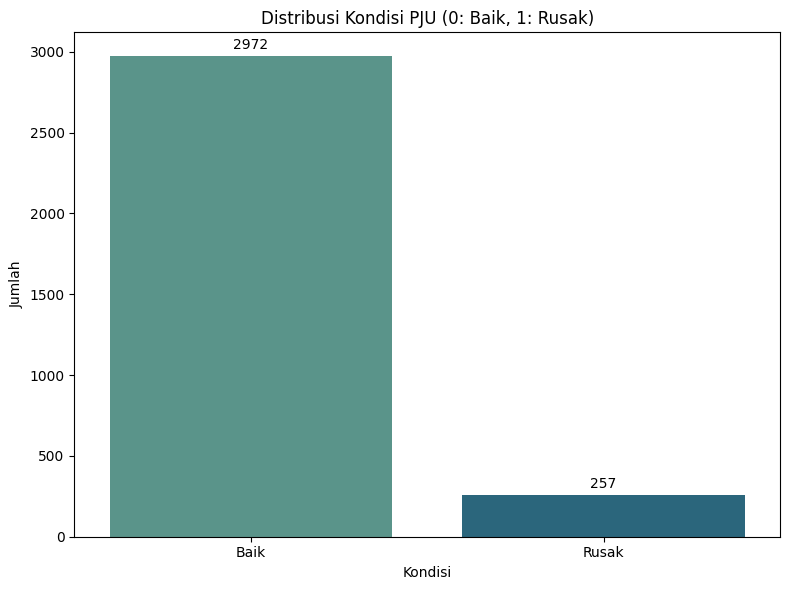

In [37]:
# Visualisasi 1: Perbandingan PJU berdasarkan Kondisi Biner
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Kondisi_Biner', data=gdf_joined, palette='crest')

plt.title('Distribusi Kondisi PJU (0: Baik, 1: Rusak)')
plt.xlabel('Kondisi')
plt.ylabel('Jumlah')
plt.xticks(ticks=[0, 1], labels=['Baik', 'Rusak'])

# Tambahkan angka di atas bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

plt.tight_layout()
plt.savefig('kondisi_pju_distribusi_biner.png')
plt.show()


In [38]:
# Simpan versi CSV final untuk arsip
gdf_joined.drop(columns="geometry").to_csv("data_pju_with_kecamatan.csv", index=False)

# Ringkasan per kecamatan & klasifikasi warna

In [39]:
# Hitung total PJU per kecamatan & jumlah rusak
pju_summary = gdf_joined.groupby("Kecamatan_Final").agg(
    total_pju=("Kondisi_Biner", "count"),
    rusak=("Kondisi_Biner", "sum")
).reset_index()

In [40]:
# Use the pju_summary DataFrame to calculate the percentage of damaged PJUs
pju_summary["persen_rusak"] = (pju_summary["rusak"] / pju_summary["total_pju"]) * 100

# Display the sub-districts with the highest percentage of damaged PJUs
display(pju_summary.sort_values("rusak", ascending=False).head())

,Kecamatan_Final,total_pju,rusak,persen_rusak
32,Sukahening,45,31,68.888889
21,Padakembang,164,23,14.024390
20,Manonjaya,185,22,11.891892
31,Sodonghilir,73,21,28.767123
19,Mangunreja,184,17,9.239130


In [41]:
# Merge ke poligon
gdf_kec_stat = gdf_kecamatan.merge(
    pju_summary, left_on="nm_kecamatan", right_on="Kecamatan_Final", how="left"
)

In [42]:
# Isi NaN (kecamatan tanpa data PJU) → total=0, rusak=0, persen=0, akan jatuh ke "Hijau"
gdf_kec_stat[["total_pju", "rusak", "persen_rusak"]] = gdf_kec_stat[["total_pju", "rusak", "persen_rusak"]].fillna(0)

In [43]:
# Kategori warna sesuai aturan detail
def kategori_warna(row):
    persen = row["persen_rusak"]

    if row["rusak"] == 0:  # 100% baik
        return "#0fac03"  # green
    elif persen > 90:
        return "#fe3203"
    elif persen > 80:
        return "#cc4e01"
    elif persen > 70:
        return "#e66d02"
    elif persen > 60:
        return "#e88201"
    elif persen > 50:
        return "#e7b200"
    elif persen > 40:
        return "#ffff01"
    elif persen > 30:
        return "#adcd00"
    elif persen > 20:
        return "#7fb300"
    elif persen > 10:
        return "#0fac03"
    else:
        return "#0fac03"  # fallback untuk sangat sedikit rusak

# Terapkan ke GeoDataFrame
gdf_kec_stat["Kategori_Warna"] = gdf_kec_stat.apply(kategori_warna, axis=1)

# Visualisasi ke geojson

In [44]:
# Pastikan CRS sama
gdf_kecamatan = gdf_kecamatan.to_crs("EPSG:4326")
gdf_joined = gdf_joined.to_crs("EPSG:4326")


In [45]:
# Mengecek koordinat yang kosong
print(gdf_joined.geometry.is_empty.sum(), "empty geometry")
print(gdf_joined.geometry.isna().sum(), "NaN geometry")


0 empty geometry
0 NaN geometry


In [46]:
# Hitung jumlah total PJU dan jumlah rusak per kecamatan
stats_kec = (
    gdf_joined.groupby("Kecamatan_Final")
    .agg(total=("Kondisi_Biner", "count"),
         rusak=("Kondisi_Biner", "sum"))
    .reset_index()
)

/tmp/ipython-input-3915514737.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="rusak", y="Kecamatan_Final", data=top10, palette="crest")


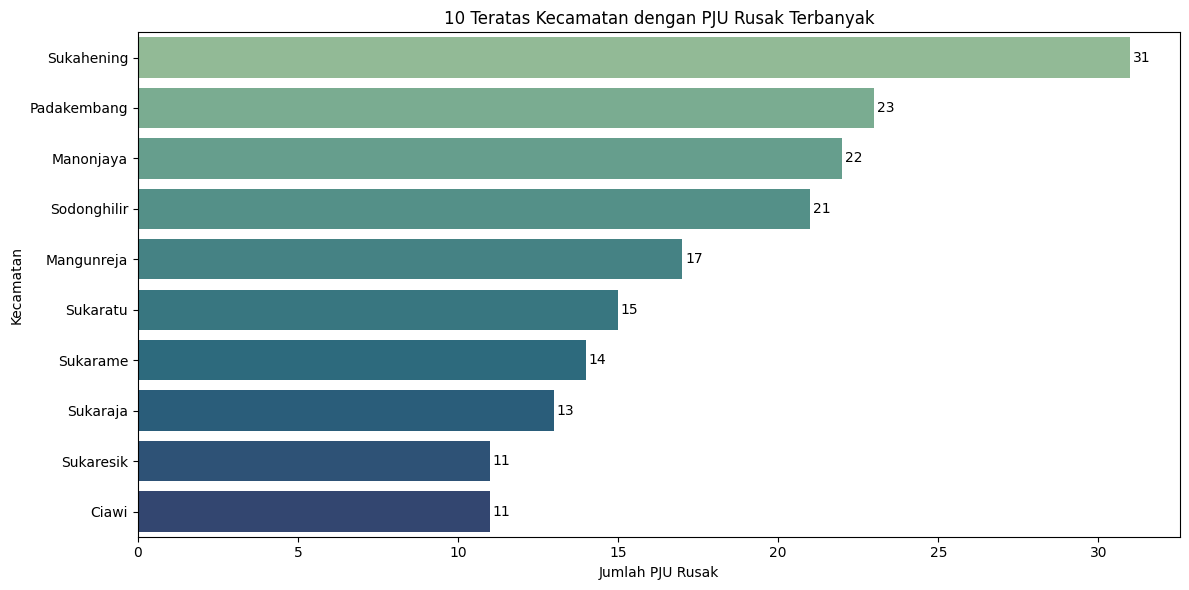

In [47]:
# Visualisasi Top 10 kecamatan dengan PJU rusak terbanyak
top10 = pju_summary.sort_values("rusak", ascending=False).head(10)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x="rusak", y="Kecamatan_Final", data=top10, palette="crest")

# Tambahkan label angka
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=2)

plt.title("10 Teratas Kecamatan dengan PJU Rusak Terbanyak")
plt.xlabel("Jumlah PJU Rusak")
plt.ylabel("Kecamatan")
plt.tight_layout()
plt.savefig("top10_kecamatan_pju_rusak.png")
plt.show()


/tmp/ipython-input-237130213.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="persen_rusak", y="Kecamatan_Final", data=top10_persen, palette="crest")


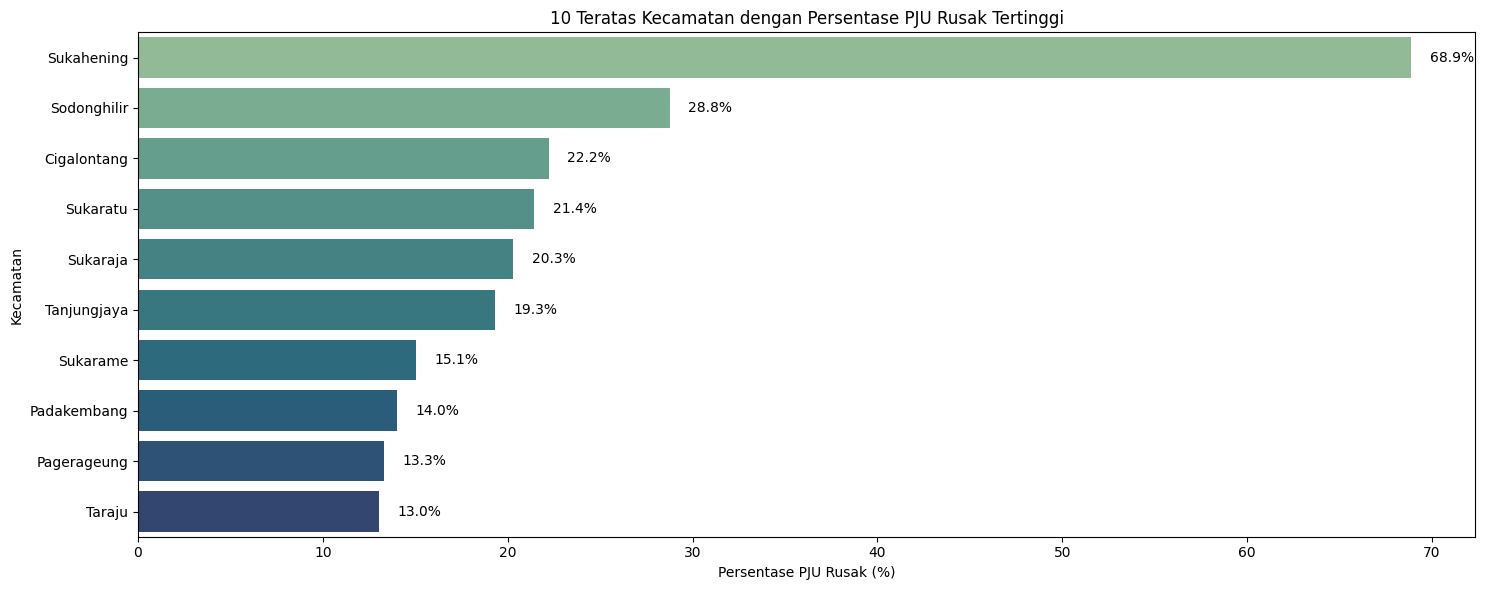

In [48]:
# Visualisasi: Top 10 Kecamatan dengan persentase PJU rusak tertinggi
top10_persen = pju_summary.sort_values("persen_rusak", ascending=False).head(10)

plt.figure(figsize=(15, 6))
ax = sns.barplot(x="persen_rusak", y="Kecamatan_Final", data=top10_persen, palette="crest")
plt.title("10 Teratas Kecamatan dengan Persentase PJU Rusak Tertinggi")
plt.xlabel("Persentase PJU Rusak (%)")
plt.ylabel("Kecamatan")

# Tambahkan label angka persentase
for i, v in enumerate(top10_persen["persen_rusak"]):
    ax.text(v + 1, i, f"{v:.1f}%", va='center')

plt.tight_layout()
plt.savefig("top10_kecamatan_persen_rusak.png")
plt.show()

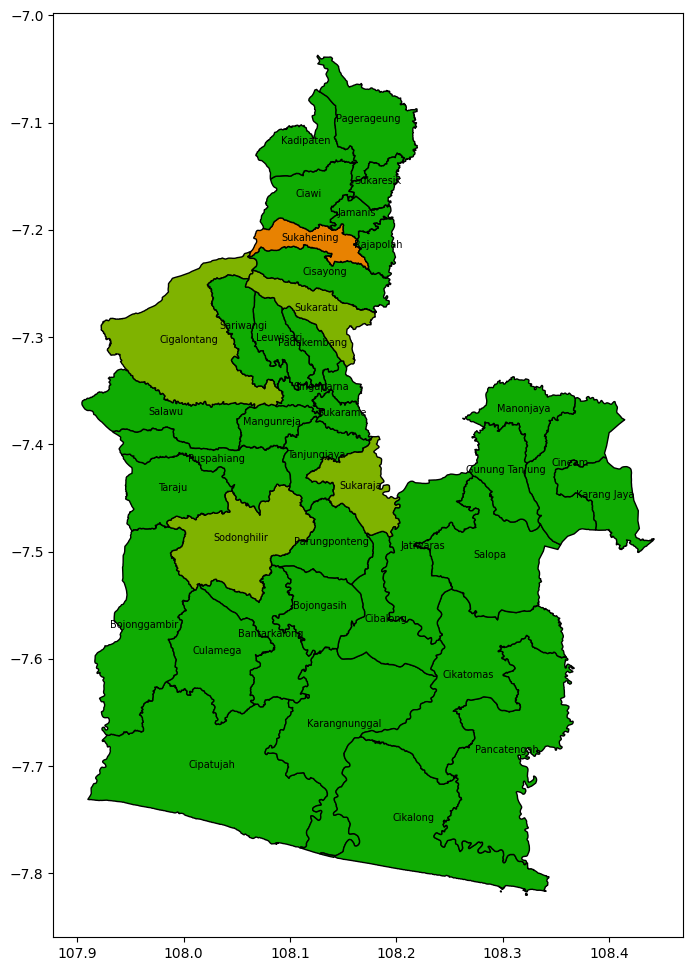

In [49]:
# Plot peta kecamatan (warna sesuai kategori rusak)
fig, ax = plt.subplots(figsize=(10, 12))
gdf_kec_stat.plot(
    ax=ax,
    color=gdf_kec_stat["Kategori_Warna"],
    edgecolor="black"
)

# Tambahkan label nama kecamatan di tengah polygon / multipolygon
for idx, row in gdf_kec_stat.iterrows():
    geom = row["geometry"]

    if geom.geom_type == "Polygon":
        # centroid langsung
        x, y = geom.centroid.coords[0]
    elif geom.geom_type == "MultiPolygon":
        # ambil poligon terbesar di dalam multipolygon
        largest_poly = max(geom.geoms, key=lambda a: a.area)
        x, y = largest_poly.centroid.coords[0]
    else:
        continue  # skip kalau bukan polygon

    ax.text(x, y, row["nm_kecamatan"], fontsize=7, ha="center")

In [50]:
import folium
from branca.element import Template, MacroElement

# Buat map center di tengah Kab. Tasikmalaya
m = folium.Map(location=[gdf_joined["Latitude"].mean(), gdf_joined["Longitude"].mean()], zoom_start=10)

# === Layer Kecamatan ===
kecamatan_layer = folium.FeatureGroup(name="Kecamatan", show=True)
folium.GeoJson(
    gdf_kec_stat,
    style_function=lambda feature: {
        "fillColor": feature["properties"]["Kategori_Warna"],
        "color": "black",
        "weight": 1,
        "fillOpacity": 0.6,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["nm_kecamatan", "total_pju", "rusak", "persen_rusak"],
        aliases=["Kecamatan", "Total PJU", "Jumlah Rusak", "Persentase Rusak"],
        localize=True
    )
).add_to(kecamatan_layer)
kecamatan_layer.add_to(m)

# === Layer PJU Baik ===
baik_layer = folium.FeatureGroup(name="PJU Baik", show=True)
for idx, row in gdf_joined[gdf_joined["Kondisi_Biner"] == 0].iterrows():
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=0.8,
        color="black",
        fill=True,
        fill_color="black",
        fill_opacity=0.7,
        popup=folium.Popup(f"""
            Kecamatan: {row['Kecamatan_Final']}<br>
            Kondisi: Baik<br>
            Jenis Lampu: {row.get('Jenis Lampu', 'Tidak diketahui')}
        """, max_width=250)
    ).add_to(baik_layer)
baik_layer.add_to(m)

# === Layer PJU Rusak ===
rusak_layer = folium.FeatureGroup(name="PJU Rusak", show=True)
for idx, row in gdf_joined[gdf_joined["Kondisi_Biner"] == 1].iterrows():
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=0.8,
        color="red",
        fill=True,
        fill_color="red",
        fill_opacity=0.8,
        popup=folium.Popup(f"""
            Kecamatan: {row['Kecamatan_Final']}<br>
            Kondisi: Rusak<br>
            Jenis Lampu: {row.get('Jenis Lampu', 'Tidak diketahui')}
        """, max_width=250)
    ).add_to(rusak_layer)
rusak_layer.add_to(m)

# Tambahkan control layer (checkbox)
folium.LayerControl(collapsed=False).add_to(m)

# === Tambahkan Legend (Kotak Keterangan) ===
legend_html = """
{% macro html(this, kwargs) %}

<div style="
    position: fixed;
    bottom: 20px; left: 20px; width: 150px; height: 70px;
    background-color: white;
    border:2px solid grey;
    z-index:9999;
    font-size:12px;
    ">
    &nbsp;<b>Keterangan PJU</b><br>
    &nbsp;<i style="background:red; border-radius:50%; width:10px; height:10px; display:inline-block"></i>&nbsp; Rusak<br>
    &nbsp;<i style="background:black; border-radius:50%; width:10px; height:10px; display:inline-block"></i>&nbsp; Baik
</div>

{% endmacro %}
"""

legend = MacroElement()
legend._template = Template(legend_html)
m.get_root().add_child(legend)

# Simpan ke HTML
m.save("peta_pju_tasik.html")
print("✅ Peta interaktif dengan legend tersimpan sebagai 'peta_pju_tasik.html'")


✅ Peta interaktif dengan legend tersimpan sebagai 'peta_pju_tasik.html'


In [51]:
output_path = os.path.join(os.getcwd(), "peta_pju_tasik.html")
m.save(output_path)
print(f"Peta interaktif tersimpan di: {output_path}")


Peta interaktif tersimpan di: /content/peta_pju_tasik.html


In [52]:
from google.colab import files
files.download("/content/peta_pju_tasik.html")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Visualisasi Insight Atribut

/tmp/ipython-input-3971290620.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


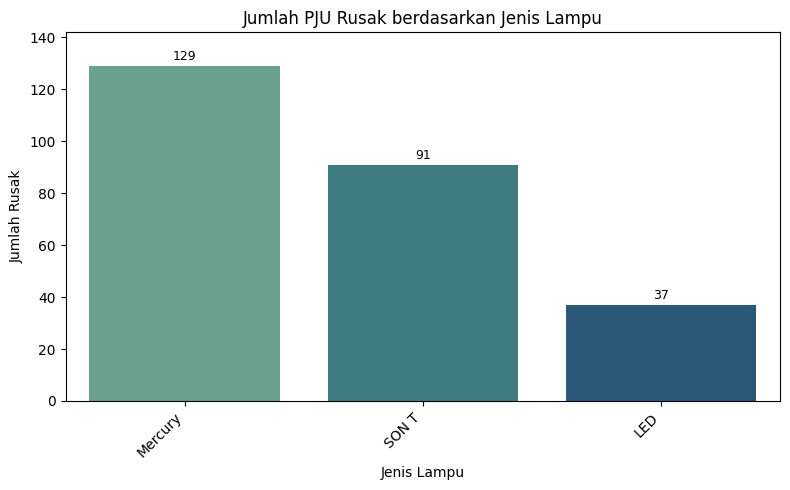

In [53]:
# === Jumlah rusak per jenis lampu ===
lampu_stats = (
    gdf_joined.groupby("Jenis Lampu")["Kondisi_Biner"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

# ubah ke seaborn agar palette crest muncul
sns.barplot(
    x=lampu_stats.index,
    y=lampu_stats.values,
    palette="crest"
)

plt.ylabel("Jumlah Rusak")
plt.title("Jumlah PJU Rusak berdasarkan Jenis Lampu")
plt.xticks(rotation=45, ha="right")

# Tambah label
for i, v in enumerate(lampu_stats.values):
    plt.text(i, v + 1, str(v), ha='center', va='bottom', fontsize=9)

plt.ylim(0, lampu_stats.max() * 1.1)
plt.tight_layout()
plt.show()


/tmp/ipython-input-1584685679.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


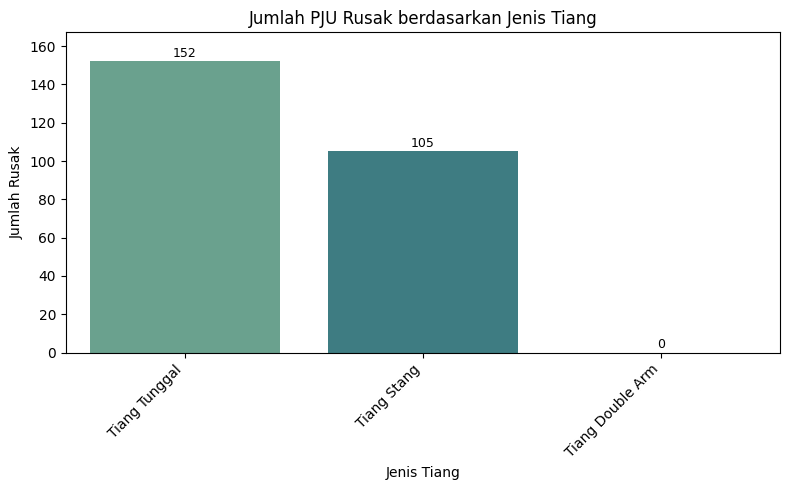

In [54]:
# === Jumlah rusak per jenis tiang ===
tiang_stats = (
    gdf_joined.groupby("Jenis Tiang")["Kondisi_Biner"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=tiang_stats.index,
    y=tiang_stats.values,
    palette="crest"
)

plt.ylabel("Jumlah Rusak")
plt.title("Jumlah PJU Rusak berdasarkan Jenis Tiang")
plt.xticks(rotation=45, ha="right")

for i, v in enumerate(tiang_stats.values):
    plt.text(i, v + 1, str(v), ha='center', va='bottom', fontsize=9)

plt.ylim(0, tiang_stats.max() * 1.1)
plt.tight_layout()
plt.show()

# Kesimpulan Umum

- Secara jumlah, kerusakan paling banyak ditemukan pada Tiang Tunggal dan Lampu Mercury.

- Namun jika dilihat persentasenya, yang paling rentan rusak adalah Tiang Stang dan Lampu Mercury.

**Rekomendasi:**

- Prioritaskan pemeliharaan pada Tiang Stang dan Lampu Mercury.

- Pertimbangkan menggunakan lampu Mercury dengan LED untuk menekan tingkat kerusakan.

# Catatan Penting

Hasil analisis ini perlu ditafsirkan dengan hati-hati karena:

- Variabel dalam dataset terbatas → hanya mencakup jenis lampu, jenis tiang, dan kondisi (baik/rusak), tanpa mempertimbangkan faktor-faktor lain yang juga memengaruhi kerusakan, seperti:

  - umur/usia pemasangan,

  - kualitas instalasi,

  - kondisi lingkungan (misalnya kelembapan, cuaca ekstrem, atau lokasi rawan kecelakaan),

  - intensitas pemakaian.

- Distribusi data tidak merata → beberapa kategori (contoh: Tiang Double Arm) jumlah populasinya sangat sedikit sehingga persentase kerusakan bisa tampak ekstrem atau menyesatkan.

- Data statis → analisis ini bersifat potret sesaat, belum mencakup dinamika kerusakan seiring waktu.

Dengan keterbatasan ini, hasil analisis lebih tepat diposisikan sebagai indikasi awal untuk menentukan prioritas pemeliharaan, bukan sebagai kesimpulan final tentang performa tiap jenis lampu/tiang.